### 지도학습 절차

- 지도학습 : 목표변수(Y)와 설명변수(X)의 관계를 학습해서, 새로운 X가 들어올 때, Y를 예측 / 분류

- 지도학습의 절차 6단계:
  1. 데이터 핸들링 (데이터 불러오기 / 파생변수 생성 / 층별화) : 데이터 구조적인 관점에서 학습을 수행할 수 있는 데이터셋을 구성하는 과정

  2. 학습에 사용될 목표변수(Y)와 설명변수(X)를 설정
    - 유의사항 : 사용되는 X는 새로 들어올 데이터에 대한 값으로 지정 ex. 신규고객 이탈 예측을 할 때 구매횟수와 방문횟수를 넣으면 안 됨.

  3. 학습 데이터(Train Set)와 검증 데이터(Test Set)분할
    - 검증 데이터(Test Set)는 학습에 참여하지 않는다! (교차검증에서 Validation Set과는 다른 개념)

  4. 학습을 수행 (Modeling)
    - 특성공학 (결측값 처리 / Encoding / Scaling ...) -> Pipe Line을 이용해서
    - 학습 (알고리즘)

  5. 학습된 모델 평가
    - 학습 능력 평가
    - 일반화 능력 평가


In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import seaborn as sns

- 사용한 데이터 (https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [2]:
# 데이터 불러오기
df1 = pd.read_csv('diabetes.csv')
print(df1.shape)
print(df1.info())
print(df1.head())
print(df1.tail())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      1

In [3]:
# 환자의 건강 관련 정보를 입력했을 때, 당뇨병에 걸릴지 말지에 대한 판별 모델 생성
# 1) 데이터 핸들링
df1['Outcome'].unique()

array([1, 0])

## **결측치는 없지만 0이 나올 수 있는 변수와 아닌 변수를 구분해서 EDA 할 것**

In [4]:
df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df1.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## **Pregrance**
 - 임신횟수

In [7]:
df1["Pregnancies"].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

In [8]:
df1["Pregnancies"].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

<Axes: >

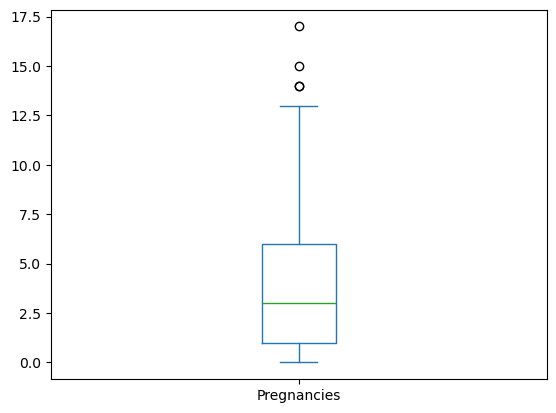

In [9]:
df1["Pregnancies"].plot(kind='box')

In [10]:
# Pregnancies 변수를 범주형 변수로 변환
def classify_pregnancies(x):
    if x == 0:
        return 0
    elif x == 1:
        return 1
    elif x == 2:
        return 2
    elif 3 <= x <= 4:
        return 3
    else:
        return 4

df1["cat_Preg"] = df1["Pregnancies"].apply(classify_pregnancies)

<Axes: xlabel='Pregnancies', ylabel='Count'>

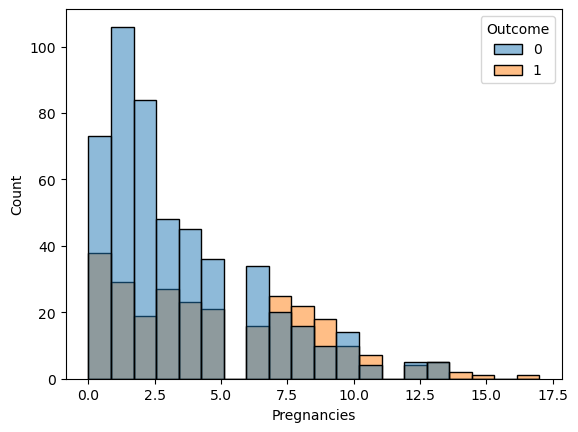

In [11]:
sns.histplot(x="Pregnancies", hue="Outcome", data=df1, bins=20)

### **변수 인사이트 정리**

Pregnancies는 정수형 값을 가진 연속형 변수.

변수 값에 따라 0번 / 1번 / 2번 / 3~4번 / 그 외 의 범주형 변수로 분류.

[그 외] 범주에서 14 이상의 값을 이상치로 봐야 할 것이다.

## **glucose**
- 혈장 포도당 농도
- 사람 혈당이 0일 수는 없다.
- 당뇨는 혈당이 지속적으로 높은 증상

In [12]:
df1["Glucose"].unique()

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 126,  99, 196, 119, 143, 147,  97,
       145, 117, 109, 158,  88,  92, 122, 138, 102,  90, 111, 180, 133,
       106, 171, 159, 146,  71, 105, 101, 176, 150,  73, 187,  84,  44,
       141, 114,  95, 129,  79,   0,  62, 131, 112, 113,  74,  83, 136,
        80, 123,  81, 134, 142, 144,  93, 163, 151,  96, 155,  76, 160,
       124, 162, 132, 120, 173, 170, 128, 108, 154,  57, 156, 153, 188,
       152, 104,  87,  75, 179, 130, 194, 181, 135, 184, 140, 177, 164,
        91, 165,  86, 193, 191, 161, 167,  77, 182, 157, 178,  61,  98,
       127,  82,  72, 172,  94, 175, 195,  68, 186, 198, 121,  67, 174,
       199,  56, 169, 149,  65, 190])

<Axes: >

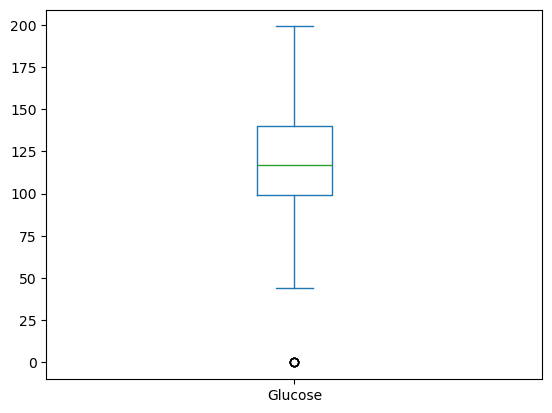

In [13]:
df1["Glucose"].plot(kind='box')

In [14]:
df1[df1["Glucose"] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg
75,1,0,48,20,0,24.7,0.140,22,0,1
182,1,0,74,20,23,27.7,0.299,21,0,1
342,1,0,68,35,0,32.0,0.389,22,0,1
349,5,0,80,32,0,41.0,0.346,37,1,4
502,6,0,68,41,0,39.0,0.727,41,1,4


In [15]:
df1.loc[df1["Glucose"] == 0, "Glucose"] = int(df1["Glucose"].mean())
int(df1["Glucose"].mean())

121

In [16]:
df1["Glucose"].unique()

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 126,  99, 196, 119, 143, 147,  97,
       145, 117, 109, 158,  88,  92, 122, 138, 102,  90, 111, 180, 133,
       106, 171, 159, 146,  71, 105, 101, 176, 150,  73, 187,  84,  44,
       141, 114,  95, 129,  79, 120,  62, 131, 112, 113,  74,  83, 136,
        80, 123,  81, 134, 142, 144,  93, 163, 151,  96, 155,  76, 160,
       124, 162, 132, 173, 170, 128, 108, 154,  57, 156, 153, 188, 152,
       104,  87,  75, 179, 130, 194, 181, 135, 184, 140, 177, 164,  91,
       165,  86, 193, 191, 161, 167,  77, 182, 157, 178,  61,  98, 127,
        82,  72, 172,  94, 175, 195,  68, 186, 198, 121,  67, 174, 199,
        56, 169, 149,  65, 190])

<Axes: xlabel='Glucose', ylabel='Count'>

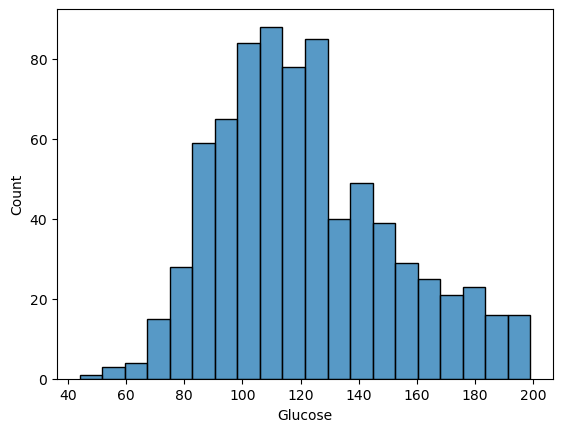

In [17]:
sns.histplot(df1["Glucose"], bins=20)

<Axes: xlabel='Glucose', ylabel='Count'>

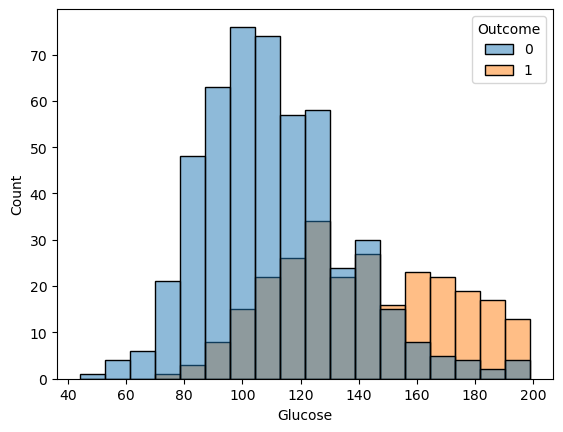

In [18]:
sns.histplot(x="Glucose", hue="Outcome", data=df1)

### **변수 인사이트 정리**

Glucose 변수는 정수형 값으로 이루어진 연속형 변수.

값이 0인 행, 즉 결측치를 데이터의 평균값인 121로 대체하였음. (0 이외의 이상치가 없었기에 중앙값이 아닌 평균값으로 대체하였음.)

처음에는 44, 57 같은 낮은 값도 이상치가 아닌가 하는 의문이 있었으나 boxplot을 그려보고 이상치가 아니라는 것을 확인할 수 있었음.

Glucose 값이 높은 환자(데이터)가 대체적으로 당뇨병이 많이 발병한다고 말할 수 있다.

## **bloodpressure**
- 혈압
- 혈압도 0일 수는 없다 

In [19]:
df1["BloodPressure"].unique()

array([ 72,  66,  64,  40,  74,  50,   0,  70,  96,  92,  80,  60,  84,
        30,  88,  90,  94,  76,  82,  75,  58,  78,  68, 110,  56,  62,
        85,  86,  48,  44,  65, 108,  55, 122,  54,  52,  98, 104,  95,
        46, 102, 100,  61,  24,  38, 106, 114])

In [20]:
df1[df1["BloodPressure"] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg
7,10,115,0,0,0,35.3,0.134,29,0,4
15,7,100,0,0,0,30.0,0.484,32,1,4
49,7,105,0,0,0,0.0,0.305,24,0,4
60,2,84,0,0,0,0.0,0.304,21,0,2
78,0,131,0,0,0,43.2,0.270,26,1,0
81,2,74,0,0,0,0.0,0.102,22,0,2
172,2,87,0,23,0,28.9,0.773,25,0,2
193,11,135,0,0,0,52.3,0.578,40,1,4
222,7,119,0,0,0,25.2,0.209,37,0,4
261,3,141,0,0,0,30.0,0.761,27,1,3


In [21]:
# bloodpressure, skinthickness, insulin 값이 모두 0인 행 제거
df1 = df1.drop(df1[(df1["BloodPressure"] == 0) & (df1["SkinThickness"] == 0) & (df1["Insulin"] == 0)].index)

In [22]:
df1[df1["BloodPressure"] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg
172,2,87,0,23,0,28.9,0.773,25,0,2
357,13,129,0,30,0,39.9,0.569,44,1,4


<Axes: >

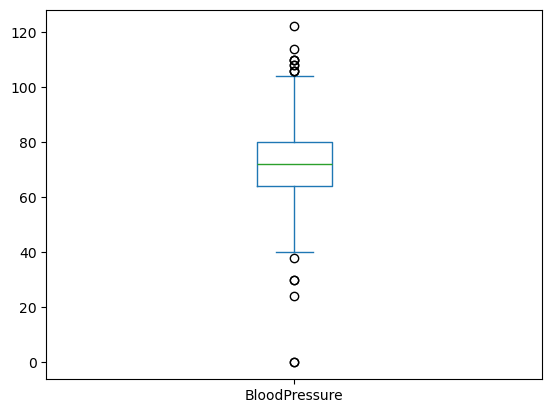

In [23]:
df1["BloodPressure"].plot(kind='box')

In [24]:
df1.loc[df1["BloodPressure"] == 0, "BloodPressure"] = df1["BloodPressure"].median()

In [25]:
df1["BloodPressure"].unique()

array([ 72,  66,  64,  40,  74,  50,  70,  96,  92,  80,  60,  84,  30,
        88,  90,  94,  76,  82,  75,  58,  78,  68, 110,  56,  62,  85,
        86,  48,  44,  65, 108,  55, 122,  54,  52,  98, 104,  95,  46,
       102, 100,  61,  24,  38, 106, 114])

<Axes: xlabel='BloodPressure', ylabel='Count'>

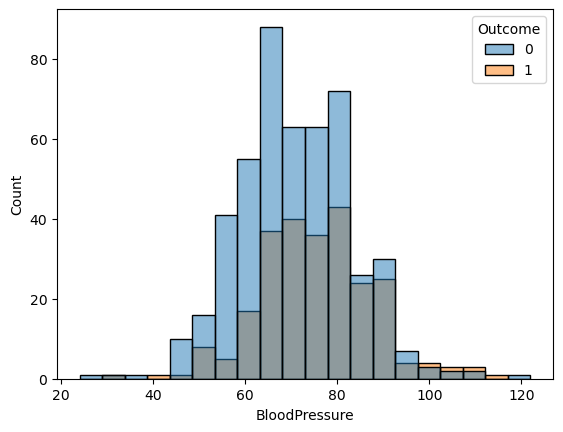

In [26]:
sns.histplot(x="BloodPressure", hue="Outcome", data=df1, bins=20)

고혈압: 수축기 혈압 140mmHg 이상 또는 이완기 혈압 90mmHg 이상

저혈압: 수축기 혈압 90mmHg 미만 또는 이완기 혈압 60mmHg 미만

출처 : https://www.k-health.com/news/articleView.html?idxno=12284

의문 : 이 데이터는 수축기 혈압인가? 이완기 혈압인가?

In [27]:
df1["BloodPressure"].describe()

count    735.000000
mean      72.404082
std       12.365295
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

최대값이 122이므로, 본 데이터의 혈압은 이완기 혈압이라고 예측 가능

In [28]:
def classify_BP(x):
    if x < 60:
        return 0 # 저혈압
    elif 60 <= x < 90:
        return 1 # 정상
    elif x >= 90:
        return 2 # 고혈압

df1["cat_BP"] = df1["BloodPressure"].apply(classify_BP)

<Axes: xlabel='cat_BP', ylabel='count'>

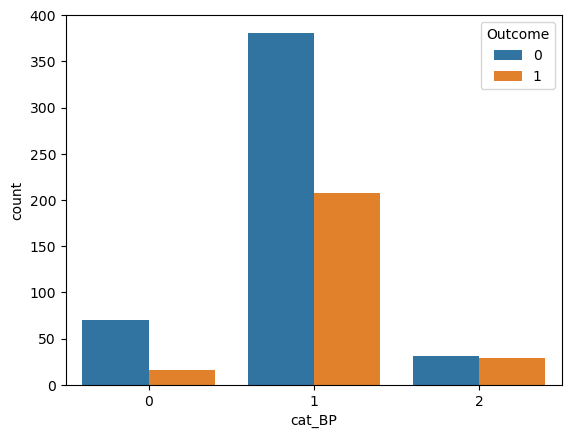

In [29]:
sns.countplot(x="cat_BP", hue="Outcome", data=df1)

### **변수 인사이트 정리**

BloodPressure 변수는 정수형 값을 가진 연속형 변수.

결측치를 처리하기 위해 0인 row를 찍어보았을 때 BloodPressure, SkinThickness, Insulin 값이 모두 0인 데이터가 많다는 것을 발견. 이를 제거함

BloodPressure 값이 0인 데이터는 이상치가 많음을 고려하여, 중앙값으로 결측치를 채움.

저 / 정상 / 고 혈압으로 나누어 변수를 범주화. 고혈압일수록 당뇨병 발병 확률가 높았음.

## **SkinThickness**
- 삼두근 피부 두께
- 체지방이란 관련이 있다.
- 0일 수 없다

In [30]:
df1["SkinThickness"].unique()

array([35, 29,  0, 23, 32, 45, 19, 47, 38, 30, 41, 33, 26, 15, 36, 11, 31,
       37, 42, 25, 18, 24, 39, 27, 21, 34, 10, 60, 13, 20, 22, 28, 54, 40,
       51, 56, 14, 17, 50, 44, 12, 46, 16,  7, 52, 43, 48,  8, 49, 63, 99])

In [31]:
df1[df1["SkinThickness"] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg,cat_BP
2,8,183,64,0,0,23.3,0.672,32,1,4,1
5,5,116,74,0,0,25.6,0.201,30,0,4,1
9,8,125,96,0,0,0.0,0.232,54,1,4,2
10,4,110,92,0,0,37.6,0.191,30,0,3,2
11,10,168,74,0,0,38.0,0.537,34,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...
757,0,123,72,0,0,36.3,0.258,52,1,0,1
758,1,106,76,0,0,37.5,0.197,26,0,1,1
759,6,190,92,0,0,35.5,0.278,66,1,4,2
762,9,89,62,0,0,22.5,0.142,33,0,4,1


<Axes: >

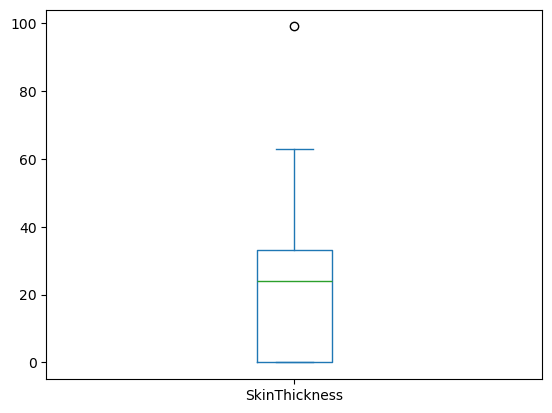

In [32]:
df1["SkinThickness"].plot(kind='box')

In [33]:
df1["SkinThickness"] = df1["SkinThickness"].replace(0, df1["SkinThickness"].median())

In [34]:
df1["SkinThickness"].unique()

array([35, 29, 24, 23, 32, 45, 19, 47, 38, 30, 41, 33, 26, 15, 36, 11, 31,
       37, 42, 25, 18, 39, 27, 21, 34, 10, 60, 13, 20, 22, 28, 54, 40, 51,
       56, 14, 17, 50, 44, 12, 46, 16,  7, 52, 43, 48,  8, 49, 63, 99])

<Axes: xlabel='SkinThickness', ylabel='Count'>

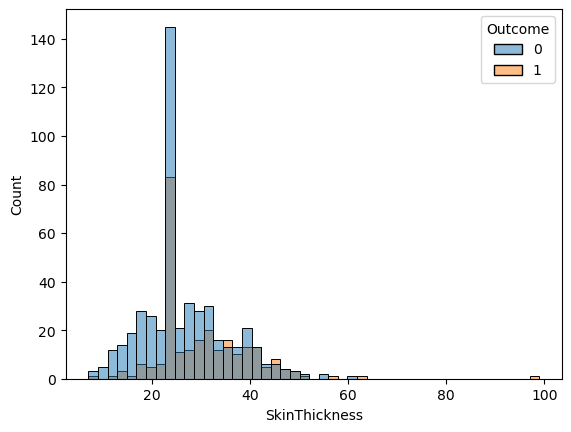

In [35]:
sns.histplot(x="SkinThickness", hue="Outcome", data=df1)

### **변수 인사이트 정리**

SkinThickness는 정수형 값을 가진 연속형 변수.

0을 결측치로 처리, 99라는 이상치가 있기에 중앙값으로 결측치를 처리하였음.

## **Insulin**
- 인슐린 분비량
- 당뇨병 유형은 인슐린이 선천적으로 나오지 않는 사람(1형)과 인슐린이 나오지만 인식을 못하는 사람(2형) 당뇨병 두가지가 있다.  

In [36]:
df1["Insulin"].unique()

array([  0,  94, 168,  88, 543, 846, 175, 230,  83,  96, 235, 146, 115,
       140, 110, 245,  54, 192, 207,  70, 240,  82,  36,  23, 300, 342,
       304, 142, 128,  38, 100,  90, 270,  71, 125, 176,  48,  64, 228,
        76, 220,  40, 152,  18, 135, 495,  37,  51,  99, 145, 225,  49,
        50,  92, 325,  63, 284, 119, 204, 155, 485,  53, 114, 105, 285,
       156,  78, 130,  55,  58, 160, 210, 318,  44, 190, 280,  87, 271,
       129, 120, 478,  56,  32, 744, 370,  45, 194, 680, 402, 258, 375,
       150,  67,  57, 116, 278, 122, 545,  75,  74, 182, 360, 215, 184,
        42, 132, 148, 180, 205,  85, 231,  29,  68,  52, 255, 171,  73,
       108,  43, 167, 249, 293,  66, 465,  89, 158,  84,  72,  59,  81,
       196, 415, 275, 165, 579, 310,  61, 474, 170, 277,  60,  14,  95,
       237, 191, 328, 250, 480, 265, 193,  79,  86, 326, 188, 106,  65,
       166, 274,  77, 126, 330, 600, 185,  25,  41, 272, 321, 144,  15,
       183,  91,  46, 440, 159, 540, 200, 335, 387,  22, 291, 39

In [37]:
df1[df1["Insulin"] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg,cat_BP
0,6,148,72,35,0,33.6,0.627,50,1,4,1
1,1,85,66,29,0,26.6,0.351,31,0,1,1
2,8,183,64,24,0,23.3,0.672,32,1,4,1
5,5,116,74,24,0,25.6,0.201,30,0,4,1
9,8,125,96,24,0,0.0,0.232,54,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1,4,1
762,9,89,62,24,0,22.5,0.142,33,0,4,1
764,2,122,70,27,0,36.8,0.340,27,0,2,1
766,1,126,60,24,0,30.1,0.349,47,1,1,1


In [38]:
df2 = df1.copy()

<Axes: xlabel='Insulin', ylabel='Count'>

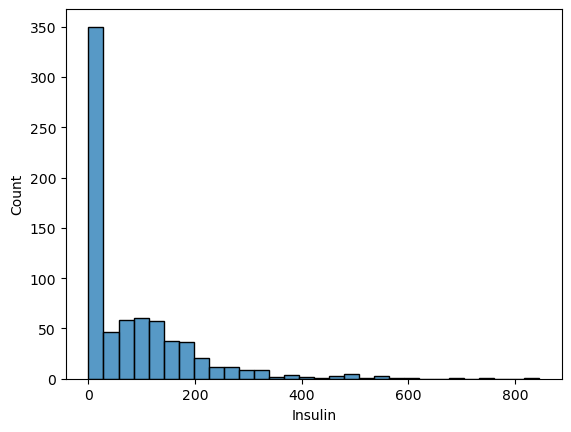

In [39]:
sns.histplot(x="Insulin", data=df1)

In [40]:
df1["Insulin"] = df1["Insulin"].replace(0, df1["Insulin"].median())

In [41]:
df1["Insulin"].unique()

array([ 45,  94, 168,  88, 543, 846, 175, 230,  83,  96, 235, 146, 115,
       140, 110, 245,  54, 192, 207,  70, 240,  82,  36,  23, 300, 342,
       304, 142, 128,  38, 100,  90, 270,  71, 125, 176,  48,  64, 228,
        76, 220,  40, 152,  18, 135, 495,  37,  51,  99, 145, 225,  49,
        50,  92, 325,  63, 284, 119, 204, 155, 485,  53, 114, 105, 285,
       156,  78, 130,  55,  58, 160, 210, 318,  44, 190, 280,  87, 271,
       129, 120, 478,  56,  32, 744, 370, 194, 680, 402, 258, 375, 150,
        67,  57, 116, 278, 122, 545,  75,  74, 182, 360, 215, 184,  42,
       132, 148, 180, 205,  85, 231,  29,  68,  52, 255, 171,  73, 108,
        43, 167, 249, 293,  66, 465,  89, 158,  84,  72,  59,  81, 196,
       415, 275, 165, 579, 310,  61, 474, 170, 277,  60,  14,  95, 237,
       191, 328, 250, 480, 265, 193,  79,  86, 326, 188, 106,  65, 166,
       274,  77, 126, 330, 600, 185,  25,  41, 272, 321, 144,  15, 183,
        91,  46, 440, 159, 540, 200, 335, 387,  22, 291, 392, 17

<Axes: xlabel='Insulin', ylabel='Count'>

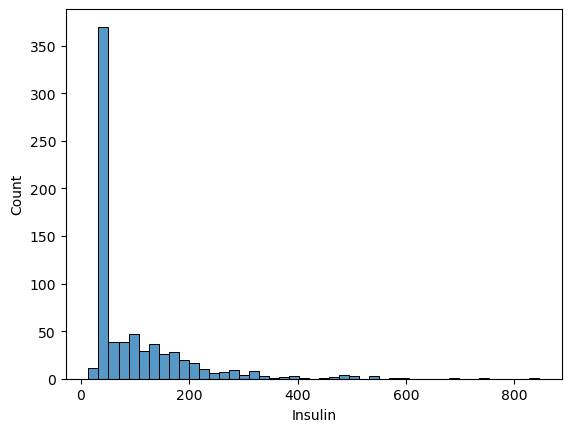

In [42]:
sns.histplot(x="Insulin", data=df1)

In [43]:
df2["Insulin"].unique()

array([  0,  94, 168,  88, 543, 846, 175, 230,  83,  96, 235, 146, 115,
       140, 110, 245,  54, 192, 207,  70, 240,  82,  36,  23, 300, 342,
       304, 142, 128,  38, 100,  90, 270,  71, 125, 176,  48,  64, 228,
        76, 220,  40, 152,  18, 135, 495,  37,  51,  99, 145, 225,  49,
        50,  92, 325,  63, 284, 119, 204, 155, 485,  53, 114, 105, 285,
       156,  78, 130,  55,  58, 160, 210, 318,  44, 190, 280,  87, 271,
       129, 120, 478,  56,  32, 744, 370,  45, 194, 680, 402, 258, 375,
       150,  67,  57, 116, 278, 122, 545,  75,  74, 182, 360, 215, 184,
        42, 132, 148, 180, 205,  85, 231,  29,  68,  52, 255, 171,  73,
       108,  43, 167, 249, 293,  66, 465,  89, 158,  84,  72,  59,  81,
       196, 415, 275, 165, 579, 310,  61, 474, 170, 277,  60,  14,  95,
       237, 191, 328, 250, 480, 265, 193,  79,  86, 326, 188, 106,  65,
       166, 274,  77, 126, 330, 600, 185,  25,  41, 272, 321, 144,  15,
       183,  91,  46, 440, 159, 540, 200, 335, 387,  22, 291, 39

In [44]:
def classify_Insulin(x):
    if x == 0:
        return 0 # 1형
    else:
        return 1 # 2형

df2["cat_Ins"] = df2["Insulin"].apply(classify_Insulin)

In [45]:
df2["cat_Ins"].value_counts()

cat_Ins
1    394
0    341
Name: count, dtype: int64

cat_Ins  Outcome
0        0          218
         1          123
1        0          264
         1          130
Name: count, dtype: int64


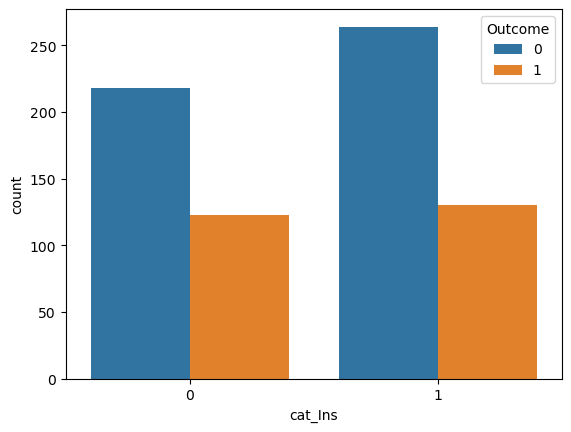

In [46]:
sns.countplot(x="cat_Ins", hue="Outcome", data=df2)

print(df2.groupby("cat_Ins")["Outcome"].value_counts())

In [47]:
ct = pd.crosstab(df2["cat_Ins"], df2["Outcome"])
ct

Outcome,0,1
cat_Ins,,
0,218,123
1,264,130


In [48]:
# 카이제곱 검정 실시
from scipy.stats import chi2_contingency

# 귀무가설(H0): cat_Ins와 Outcome는 독립이다.
# 대립가설(H1): cat_Ins와 Outcome는 독립이 아니다.

chi2, p_value, dof, expected = chi2_contingency(ct)

print('카이제곱 검정 결과')
print('카이제곱 통계량:', round(chi2, 4))
print('p-value:', round(p_value, 4))
print('자유도:', dof)
print('기대도수:\n', expected)

if p_value < 0.05:
    print('\n결론: 유의수준 0.05에서 귀무가설을 기각합니다.')
    print('즉, cat_Ins와 Outcome는 서로 관련이 있다고 볼 수 있습니다.')
else:
    print('\n결론: 유의수준 0.05에서 귀무가설을 기각하지 못합니다.')
    print('즉, cat_Ins와 Outcome는 독립이다.')

카이제곱 검정 결과
카이제곱 통계량: 0.6357
p-value: 0.4253
자유도: 1
기대도수:
 [[223.62176871 117.37823129]
 [258.37823129 135.62176871]]

결론: 유의수준 0.05에서 귀무가설을 기각하지 못합니다.
즉, cat_Ins와 Outcome는 독립이다.


### **변수 인사이트 정리**


Insulin 값이 0이라고 해서 이를 섣불리 결측치라고 판단할 수 없다. 1형 당뇨는 인슐린이 생성되지 않으므로..

그렇다고 Insulin이 0인 row와 Outcome이 0인 데이터를 비교하여 볼 수 없을 것이다. 종속 변수를 전처리 과정에 사용하면 안되므로...

그렇다면 ? Insulin 값이 0인 데이터가 모두 1형 당뇨병 케이스라고 치부하거나, 무시하고 결측치 처리하는 2가지 방법이 있다.

df1에서는 0값을 모두 결측치로 보고, 이를 중앙값으로 대체하였다. 중앙값으로 대체한 이유는 이상치의 영향을 줄이기 위함이다.

df2에서는 insulin == 0값을 1형 / 그 외를 2형으로 범주화하였다.

범주화한 변수에 groupby하여 보았을 때, Insulin 이 0인 데이터가 당뇨병에 걸린 경우가 더 많았다. -> 0을 결측치가 아닌 관측될 수 있는 데이터로 받아들일 만 하다.

##### 변수의 특성에 따라 같은 값이라도 의미를 다르게 해석하는 자세가 필요

## **BMI**
- 0이 나올 수 없는 값

In [49]:
df1["BMI"].unique()

array([33.6, 26.6, 23.3, 28.1, 43.1, 25.6, 31. , 30.5,  0. , 37.6, 38. ,
       27.1, 30.1, 25.8, 45.8, 29.6, 43.3, 34.6, 39.3, 35.4, 39.8, 29. ,
       36.6, 31.1, 39.4, 23.2, 22.2, 34.1, 36. , 31.6, 24.8, 19.9, 27.6,
       24. , 33.2, 32.9, 38.2, 37.1, 34. , 40.2, 22.7, 45.4, 27.4, 42. ,
       29.7, 28. , 39.1, 19.4, 24.2, 24.4, 33.7, 34.7, 23. , 37.7, 46.8,
       40.5, 41.5, 25. , 25.4, 32.8, 32.5, 42.7, 19.6, 28.9, 28.6, 43.4,
       35.1, 32. , 24.7, 32.6, 22.4, 29.3, 24.6, 48.8, 32.4, 38.5, 26.5,
       19.1, 46.7, 23.8, 33.9, 20.4, 28.7, 49.7, 39. , 26.1, 22.5, 39.6,
       29.5, 34.3, 37.4, 33.3, 31.2, 28.2, 53.2, 34.2, 26.8, 55. , 42.9,
       34.5, 27.9, 38.3, 21.1, 33.8, 30.8, 36.9, 39.5, 27.3, 21.9, 40.6,
       47.9, 50. , 25.2, 40.9, 37.2, 44.2, 29.9, 31.9, 28.4, 43.5, 32.7,
       67.1, 45. , 34.9, 27.7, 35.9, 22.6, 33.1, 30.4, 24.3, 22.9, 34.8,
       30.9, 40.1, 23.9, 37.5, 35.5, 42.8, 42.6, 41.8, 35.8, 30. , 37.8,
       28.8, 23.6, 35.7, 36.7, 45.2, 44. , 46.2, 35

<Axes: ylabel='Frequency'>

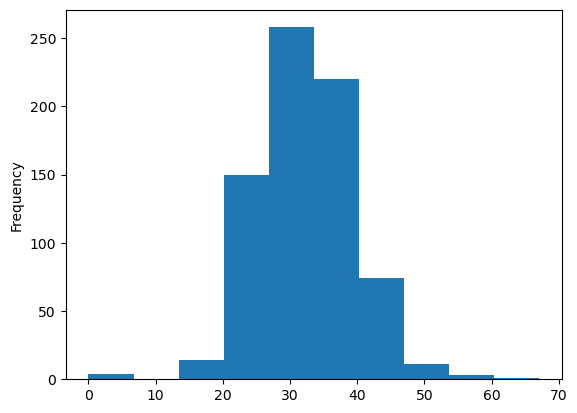

In [50]:
df1["BMI"].plot(kind='hist')

In [51]:
df1["BMI"].describe()

count    735.000000
mean      32.298503
std        7.268129
min        0.000000
25%       27.400000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

<Axes: >

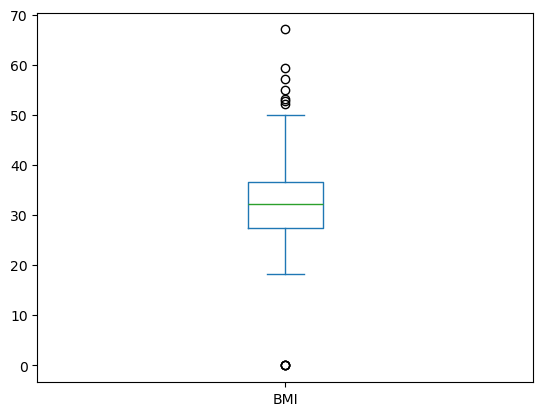

In [52]:
df1["BMI"].plot(kind='box')

In [53]:
df1["BMI"] = df1["BMI"].replace(0, df1["BMI"].median())

<Axes: >

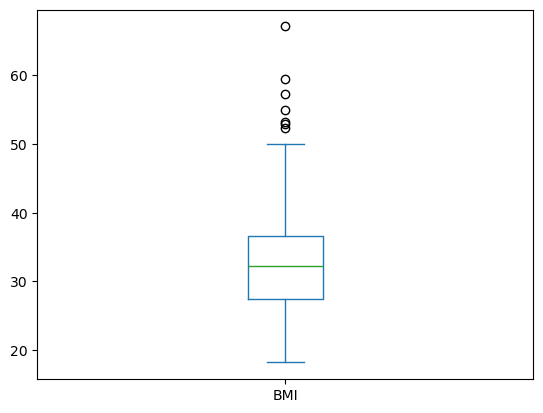

In [54]:
df1["BMI"].plot(kind='box')

<Axes: xlabel='BMI', ylabel='Count'>

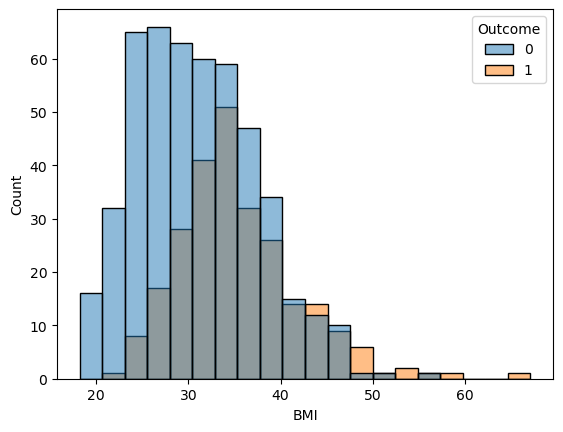

In [55]:
sns.histplot(x="BMI", hue="Outcome", data=df1, bins=20)

### **변수 인사이트 정리**

BMI는 연속형 변수.

이상치가 많이 존재하므로 median 으로 결측값을 처리하였다.

Glucose 변수와 마찬가지로 BMI 변수도 Outcome 변수에 영향을 미치는 것으로 보임.

## **파생변수 생성 및 추가 전처리**

In [56]:
df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg,cat_BP
0,6,148,72,35,45,33.6,0.627,50,1,4,1
1,1,85,66,29,45,26.6,0.351,31,0,1,1
2,8,183,64,24,45,23.3,0.672,32,1,4,1
3,1,89,66,23,94,28.1,0.167,21,0,1,1
4,0,137,40,35,168,43.1,2.288,33,1,0,0


### BMI 별 비만지수


저체중 : 18.5미만

정상 : 18.5이상 ~ 22.9이하

비만전단계 : 23이상 ~ 24.9이하

1단계 비만 : 25이상 ~ 29.9이하

2단계 비만 : 30이상 ~ 34.9이하

3단계 비만 : 35이상

출처 : https://www.hanam.go.kr/health/contents.do?key=8926 

In [57]:
def classify_BMI(x):
    if x <18.5:
        return 0 # 저체중
    elif 18.5 <= x < 25:
        return 1 # 정상
    elif 25 <= x < 30:
        return 2 # 1단계
    elif 30 <= x < 35:
        return 3 # 2단계
    elif x >= 35:
        return 4 # 3단계
    
df1["cat_BMI"] = df1["BMI"].apply(classify_BMI)

In [58]:
# 나이에 따른 범주화

def classify_age(x):
    if x < 30:
        return 0 # 30세 미만
    elif 30 <= x < 40:
        return 1 # 30~39세
    elif 40 <= x < 50:
        return 2 # 40~49세
    elif 50 <= x < 60:
        return 3 # 50~59세
    elif x >= 60:
        return 4 # 60세 이상

df1["cat_age"] = df1["Age"].apply(classify_age)

In [77]:
df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg,cat_BP,cat_BMI,cat_age
0,6,148,72,35,45,33.6,0.627,50,1,4,1,3,3
1,1,85,66,29,45,26.6,0.351,31,0,1,1,2,1
2,8,183,64,24,45,23.3,0.672,32,1,4,1,1,1
3,1,89,66,23,94,28.1,0.167,21,0,1,1,2,0
4,0,137,40,35,168,43.1,2.288,33,1,0,0,4,1


# **모델링하기**

In [78]:
# 2) 목표변수 / 설명변수 설정
# 파생 변수는 추가하고, 필요 없는 변수는 빼기

X = df1[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Age', 'cat_Preg', 'cat_BP', 'cat_BMI', 'cat_age']]
Y = df1['Outcome'] # Y값에는 결측치가 존재해서는 안됨

In [79]:
# 3) 학습데이터와 검증데이터를 분할
# pip install scikit-learn
from sklearn.model_selection import train_test_split

In [80]:
train_test_split(X,Y) # X 데이터의 학습, 검증 데이터 & Y 데이터의 학습, 검증데이터 4개로 분리됨

[     Pregnancies  Glucose  BloodPressure  SkinThickness   BMI  Age  cat_Preg  \
 136            0      100             70             26  30.8   21         0   
 431            3       89             74             16  30.4   38         3   
 465            0      124             56             13  21.8   21         0   
 301            2      144             58             33  31.6   25         2   
 573            2       98             60             17  34.7   22         2   
 ..           ...      ...            ...            ...   ...  ...       ...   
 486            1      139             62             41  40.7   21         1   
 188            8      109             76             39  27.9   31         4   
 17             7      107             74             24  29.6   31         4   
 267            2      128             64             42  40.0   24         2   
 59             0      105             64             41  41.5   22         0   
 
      cat_BP  cat_BMI  cat

In [81]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1234)
# train_test_split()에 별도의 옵션을 지정하지 않으면 75:25로 학습:검증 분할됨
# random_state을 지정해야 같은 결과가 나옴

In [82]:
X.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
Age              0
cat_Preg         0
cat_BP           0
cat_BMI          0
cat_age          0
dtype: int64

=> X에도 결측치가 없는 데이터이지만, 추후 새로 들어올 데이터에 결측치가 존재할 수 있음

+ df2(Insulin 변수의 0값을 결측치로 처리하지 않은 데이터)도 모델링해봄.

In [65]:
df2["cat_BMI"] = df2["BMI"].apply(classify_BMI)
df2["cat_age"] = df2["Age"].apply(classify_age)
df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cat_Preg,cat_BP,cat_Ins,cat_BMI,cat_age
0,6,148,72,35,0,33.6,0.627,50,1,4,1,0,3,3
1,1,85,66,29,0,26.6,0.351,31,0,1,1,0,2,1
2,8,183,64,24,0,23.3,0.672,32,1,4,1,0,1,1
3,1,89,66,23,94,28.1,0.167,21,0,1,1,1,2,0
4,0,137,40,35,168,43.1,2.288,33,1,0,0,1,4,1


In [66]:
# 2) 목표변수 / 설명변수 설정
# 파생 변수는 추가하고, 필요 없는 변수는 빼기

#X = df2[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Age', 'cat_Preg', 'cat_BP', 'cat_Ins']]
#Y = df2['Outcome'] # Y값에는 결측치가 존재해서는 안됨

#train_test_split(X,Y) # X 데이터의 학습, 검증 데이터 & Y 데이터의 학습, 검증데이터 4개로 분리됨

# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1234)
# train_test_split()에 별도의 옵션을 지정하지 않으면 75:25로 학습:검증 분할됨
# random_state을 지정해야 같은 결과가 나옴


실행한 결과 정확도가 df1보다 떨어짐.

# **각자 공부한 모델 쓰기**

### RandomForest : DecisionTree의 군집

+ 응답의 혼잡도, 즉 지니계수(Gini Impurity)를 낮추는 방향으로 질문을 생성함. 여기서 질문은 나무라고 할 수 있고 이 나무들이 모여서 숲이 되는 것!

+ DecisioonTree의 질문들은 지니계수를 낮추는 데에 목적이 있고, 어떤 변수가 가장 지니계수를 낮추는데 크게 기여했는지를 합산하여 이것을 바탕으로 변수 중요도 순위를 매김.

+ RandomForest는 동일한 데이터셋에서 랜덤하게 추출한 서로 다른 데이터 샘플로 여러개의 DecisionTree를 생성하고, 새로운 데이터가 생성되면 기존의 Tree의 다수결로 통합하여 의사결정하는 알고리즘임.

+ RandomForest는 BootStrap Sampling과 Feature Bagging 기법을 사용
    - BootStrap Sampling : 전체 데이터에서 중복을 허용하여 무작위로 샘플을 뽑는 방식
    - Feature Bagging : 모든 특성 중 일부만 무작위로 선택하여 학습하는 방식

+ RandomForest의 장점
    1. 뛰어난 성능 : 배깅 기반 알고리즘으로 튜닝을 따로 하지 않아도 좋은 성능이 나온다. 
    2. 과적합(Overfitting)에 강함 : 여러 결정 트리의 앙상블이라 단일 트리보다 과적합에 강하고 일반화 성능이 좋음
    3. 다양한 데이터 타입 처리 가능 : 범주형/수치형 데이터 모두 처리 가능
    4. 이상치/결측치에 덜 민감 : 여러 트리의 평균/다수결이라 특정 이상치의 영향이 희석됨

* RandomForest의 단점
    1. 해석 어려움 : 트리 하나는 해석이 쉽지만, 수백 개 트리의 모집(숲)은 개별 결정 트리처럼 직관적으로 설명하기 어려움 (블랙박스 모델)
    2. 계산 비용/메모리 부담 : 트리 개수가 많아지면 학습·예측 시간과 메모리 사용량이 증가


출처  : https://www.youtube.com/watch?v=vutU-SLTZ-A

In [83]:
# 4) 학습 수행
from sklearn.ensemble import RandomForestClassifier

In [84]:
model = RandomForestClassifier(random_state=1234) # 랜덤포레스트 모델 생성
model.fit(X_train, Y_train) # 학습 수행

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1234
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap boots

In [85]:
# 5) 성능 확인
from sklearn.metrics import accuracy_score
# 정확도 : 전체 데이터 중 얼만큼 정확히 분류했는지 비율

In [86]:
Y_train_pred = model.predict(X_train)

In [87]:
Y_test_pred = model.predict(X_test)

In [88]:
print('학습 정확도 : ', accuracy_score(Y_train, Y_train_pred)) # 여러 알고리즘에 대한 모델을 비교할 때 확인해야 함
print('검증 정확도 : ', accuracy_score(Y_test, Y_test_pred))

학습 정확도 :  1.0
검증 정확도 :  0.7880434782608695


### 과적합(Overfitting)

- 과적합 : 학습 데이터에 대해서는 Model이 높은 성능을 나타내지만, 검증데이터에서는 성능이 낮게 나오는 현상
- 해결 : 특성공학을 통해 데이터를 더 깔끔하게 생성

### 특성공학(Feature Engineering)
- **특성공학** : 학습의 목적에 맞게(학습이 잘 수행될 수 있도록) 데이터를 깔끔하게 다듬는 작업
- 대표적 기법 : 
  1. Scaling & Encoding : 숫자 데이터의 스케일을 맞추거나, 문자 데이터를 숫자로 변환하여 학습에 사용
  2. Imputation : 데이터 상에 존재하는 결측값에 대해 다른 값으로 대치 (새로 들어오는 데이터가 결측일 수도 있기 때문에)
  3. Cross Validation (교차검증): 학습데이터를 여러 단계로 나누어 분할하여 학습
  4. Hyper Parameter Tuning : 학습 알고리즘 내 존재하는 수학적 구조나 학습에 발생하는 구조, 함수들을 사용자가 통제
  5. Imbalanced Data Sampling : 목표변수의 비율이 깨져있는 데이터를 맞추어 학습
  6. Feature Selection : 목표변수에 가장 영향이 있는 인자를 사용자가 지정한 만큼 선택해서 학습
  7. PCA : 데이터의 차원을 줄이거나 특성을 재구성하여 학습

- Scikit Learn에서 특성공학 기법과 학습을 동시에 수행할 수 있게 Pipe Line 구성하여 학습을 수행

In [89]:
# 4) 학습 수행
from sklearn.pipeline import make_pipeline # 특성공학 + 학습
from sklearn.impute import SimpleImputer # 결측값 단순 대치 기법
from sklearn.tree import DecisionTreeClassifier # 학습 알고리즘(의사결정나무)
from sklearn.preprocessing import StandardScaler #Standard Scaling

In [98]:
# 파이프라인 구조 설계
# 스케일링 하고 싶으면 StandardScaler() 사용

model_pipe = make_pipeline(
    SimpleImputer(strategy='median'), # 결측값 처리
    StandardScaler(), # 스케일링
    RandomForestClassifier(random_state=1234)
)
model_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive est

In [99]:
from sklearn.model_selection import GridSearchCV

#### **RandomForest 모델의 하이퍼파라미터**

1. 트리 개수 관련

    * n_estimators : 생성할 트리(결정 트리)의 개수, 많을수록 성능 안정적이지만 계산 비용 증가, 일반적으로 100~500 사이

2. 개별 트리 구조 관련

    * max_depth : 각 트리의 최대 깊이, 너무 깊으면 과적합, 너무 얕으면 과소적합 , None으로 두면 리프가 순수해질 때까지 분할 (과적합 위험)

    * min_samples_split : 노드를 분할하기 위해 필요한 최소 샘플 수, 값이 클수록 트리가 단순해짐 (과적합 방지)

    * min_samples_leaf : 리프 노드가 가져야 할 최소 샘플 수, 값이 클수록 트리가 부드러워짐 (노이즈에 덜 민감)

    * max_leaf_nodes : 리프 노드의 최대 개수 제한

    * min_impurity_decrease :분할로 인한 불순도 감소가 이 값 이상일 때만 분할 수행

3. 특성(변수) 샘플링 관련

    * max_features: 각 분할 시 고려할 최대 특성 개수

        분류: 보통 sqrt(전체 특성 수)

        회귀: 보통 전체 특성 수 / 3

        이 값이 작을수록 트리 간 상관관계 낮아짐 (다양성↑) → 분산 감소 효과 커짐

4. 데이터 샘플링(배깅) 관련

    * bootstrap : 부트스트랩 샘플링 사용 여부 (기본 True), False면 전체 데이터로 각 트리 학습 (배깅 효과 사라짐)

    * max_samples : bootstrap=True일 때, 각 트리가 사용할 샘플 비율/개수

    * oob_score : Out-of-Bag 샘플(부트스트랩에서 제외된 데이터)로 성능 검증할지 여부, 별도 검증셋 없이도 일반화 성능 추정 가능

5. 기타

    * criterion : 분할 기준

        분류: gini, entropy, log_loss

        회귀: squared_error, absolute_error 등

    * class_weight : 클래스 불균형 문제에서 클래스별 가중치 조정 (balanced 옵션 자주 사용)

    * random_state : 재현성을 위한 랜덤 시드

    * n_jobs : 병렬 처리에 사용할 CPU 코어 수 (-1이면 전체 코어 사용)


In [117]:
# 하이퍼파라미터 튜닝 및 교차검증
hyperparam = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [3, 5, 7]  
}

grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3,
                          scoring='f1', n_jobs=-1)
grid_model1.fit(X_train, Y_train)
best_model1 = grid_model1.best_estimator_

In [118]:
best_model1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Pregnancies','Glucose','BloodPressure',...,'cat_BP','cat_BMI','cat_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. Fo

In [119]:
# 5) 평가
Y_train_pred = best_model1.predict(X_train) # 학습 데이터의 예측값 계산
Y_test_pred = best_model1.predict(X_test) # 검증데이터의 예측값 계산

In [120]:
from sklearn.metrics import classification_report

In [121]:
# 학습 성능 평가
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       366
           1       0.90      0.88      0.89       185

    accuracy                           0.93       551
   macro avg       0.92      0.91      0.92       551
weighted avg       0.93      0.93      0.93       551



In [116]:
# 일반화 성능 평가
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.93      0.84       116
           1       0.81      0.50      0.62        68

    accuracy                           0.77       184
   macro avg       0.79      0.72      0.73       184
weighted avg       0.78      0.77      0.76       184



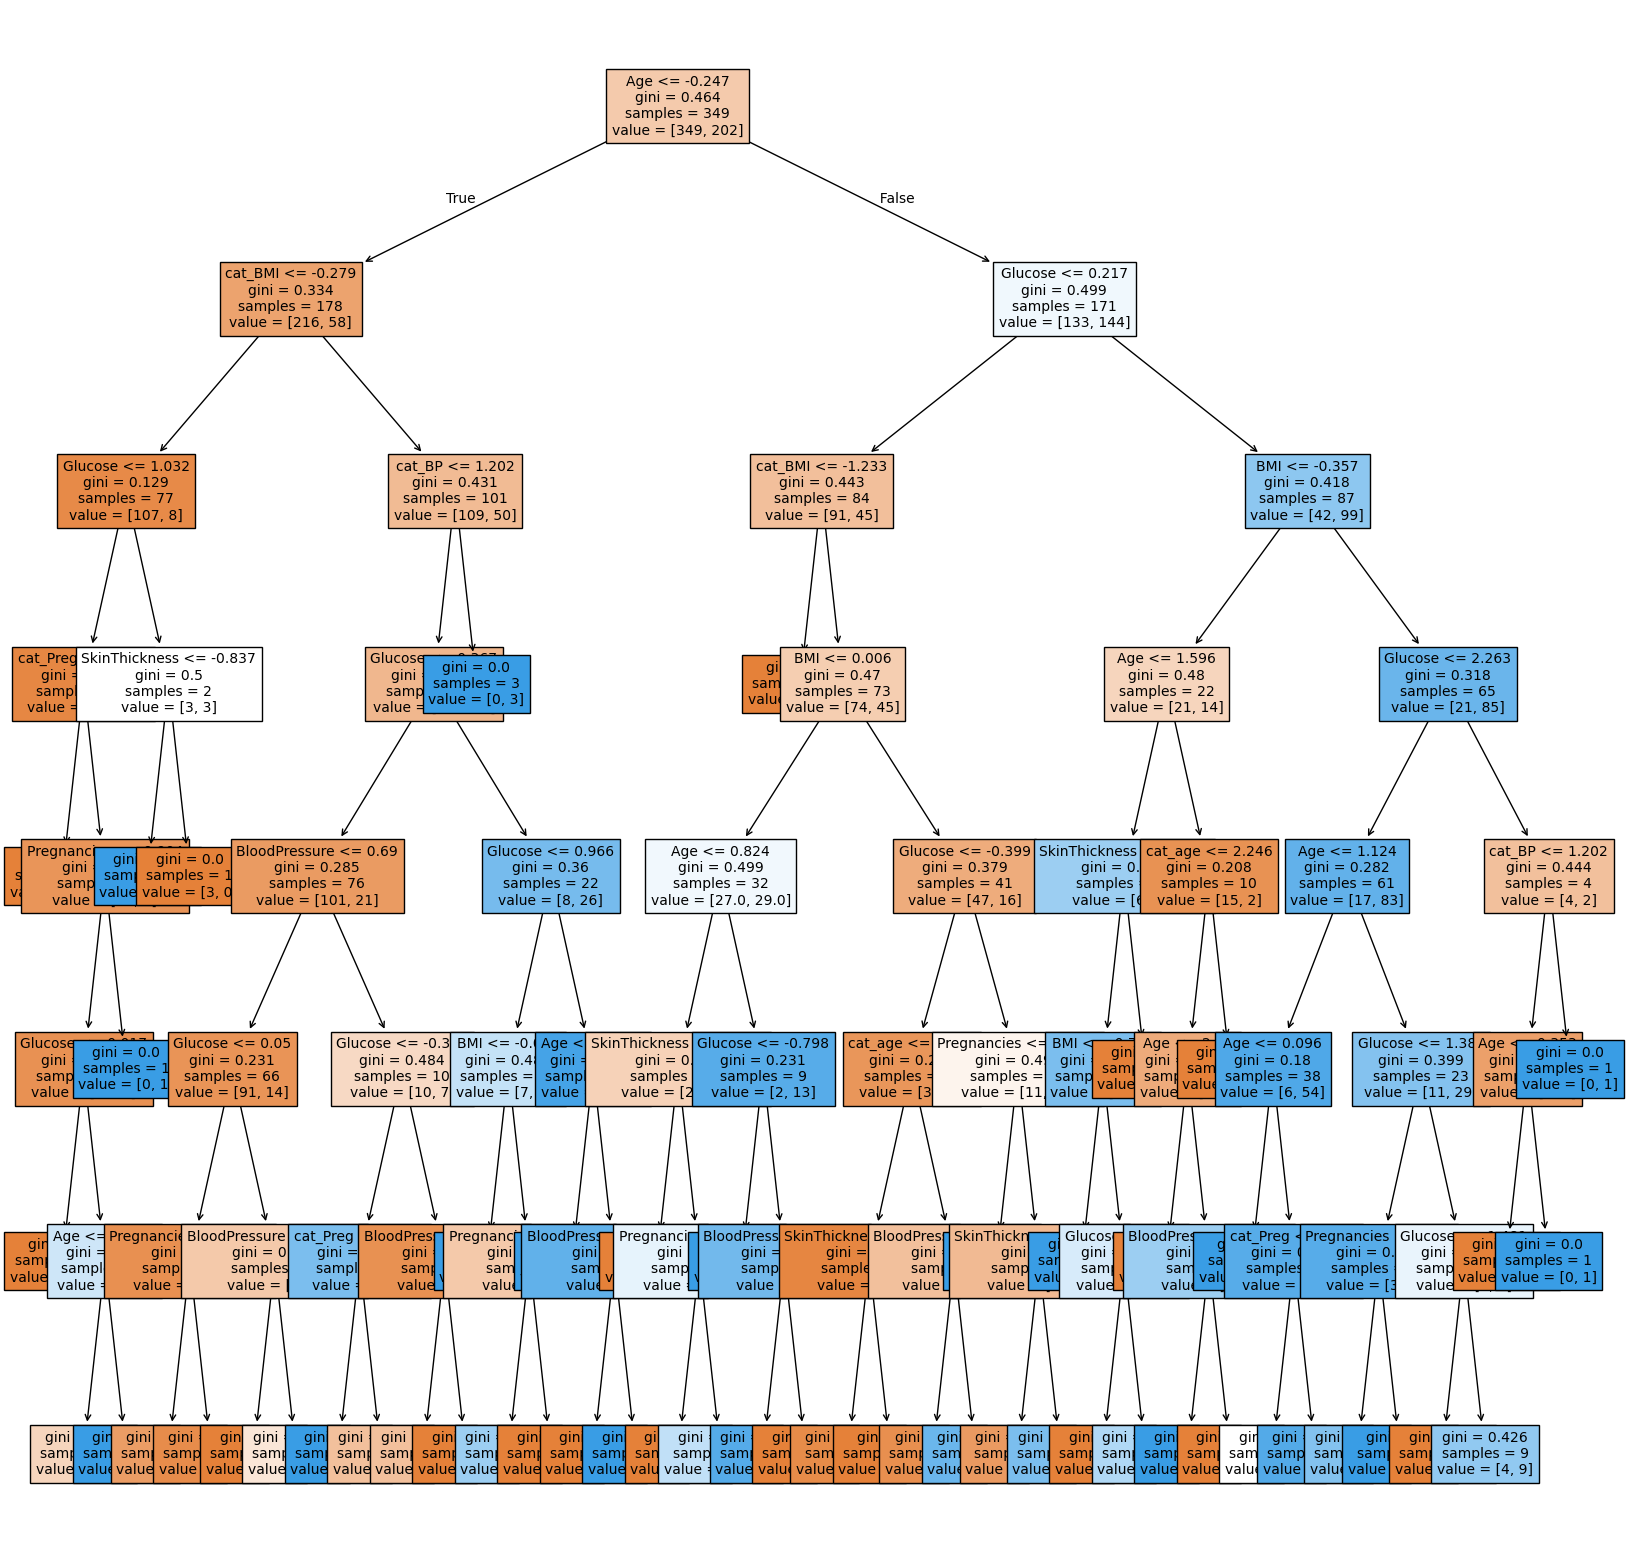

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
tree = plot_tree(best_model1.named_steps['randomforestclassifier'].estimators_[0],
                 feature_names=X.columns, filled=True, fontsize=10)

# randomforestclassifier에서 사용한 estimators_ 중 첫 번째 의사결정나무 (best_model1)를 시각화

# **성능을 높이기 위한 방안**

1. test 데이터의 정확도가 test 데이터의 정확도보다 많이 낮으면 과적합
2. 하이퍼파라미터 튜닝, 추가적인 전처리(변수 제거) 혹은 파생변수 생성 으로 이를 해결 할 수 있다.  